## TS-diagram Eddy

In [1]:
# submesoscale eddy
from smode_import import *
from parula import parula
from cmocean import cm as cm

In [2]:
# Underway data
path = '/Users/elise/data/SMODE-data/'
uw = xr.open_dataset(path+'TSG/'+'IOP2_underway.nc')

# CMEMS data
thetao = xr.open_dataset('/Users/elise/ocean/drifters_chl/other/CMEMS_potTemp_march-may2023.nc').thetao.sel(depth=slice(0,5))
so     = xr.open_dataset('/Users/elise/ocean/drifters_chl/other/CMEMS_salinity_march-may2023.nc').so.sel(depth=slice(0,5))

In [4]:
xr.open_dataset('/Users/elise/ocean/drifters_chl/other/CMEMS_potTemp_march-may2023.nc')

<xarray.Dataset> Size: 233MB
Dimensions:    (time: 62, depth: 13, latitude: 241, longitude: 300)
Coordinates:
  * time       (time) datetime64[ns] 496B 2023-03-01 2023-03-02 ... 2023-05-01
  * depth      (depth) float32 52B 0.494 1.541 2.646 3.819 ... 15.81 18.5 21.6
  * latitude   (latitude) float32 964B 30.0 30.08 30.17 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 1kB -140.0 -139.9 -139.8 ... -115.2 -115.1
Data variables:
    thetao     (time, depth, latitude, longitude) float32 233MB ...
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institution:       Mercator Ocean International
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MOI GLO12
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           https://marine.copernicus.eu/contact
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_ANALYSISFORECAST_PHY_001_024
    subset:datasetId:  cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m_202406
    subset:date:       2025-04-28T21:06:53.165Z

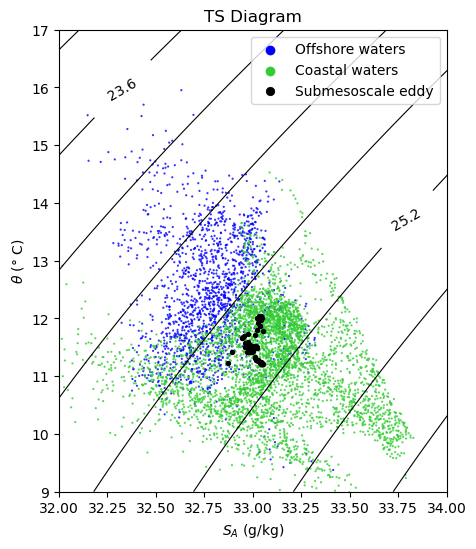

In [14]:
# TS diagram of CMEMS
plt.figure(figsize=(5,6))


# CMEMS offshore waters
ss=200
lon_slice, lat_slice = slice(-132,-123), slice(36,38)
thetao_sel=thetao.sel(time='2023-04',latitude=lat_slice,longitude=lon_slice)#.isel(depth=0)
so_sel=so.sel(time='2023-04',latitude=lat_slice,longitude=lon_slice)#.isel(depth=0)
plt.scatter(so_sel.values.flatten()[::ss],thetao_sel.values.flatten()[::ss],
            s=10, facecolors='blue',marker='.', 
            edgecolors='none',alpha=0.8)

# CMEMS coastal waters
ss=2
lon_slice, lat_slice = slice(-123,-120), slice(36,38)
thetao_sel=thetao.sel(time='2023-04',latitude=lat_slice,longitude=lon_slice).isel(depth=0)
so_sel=so.sel(time='2023-04',latitude=lat_slice,longitude=lon_slice).isel(depth=0)
plt.scatter(so_sel.values.flatten()[::ss],thetao_sel.values.flatten()[::ss],
            s=10, facecolors='limegreen', marker='.',
            edgecolors='none',alpha=0.8)


# add uw data
times_crossings = [
    ['2023-04-20T03:20:00', '2023-04-20T05:00:00'],
    ['2023-04-20T21:00:00', '2023-04-20T23:00:00'],
    ['2023-04-21T16:40:00', '2023-04-21T17:25:00'],
    ['2023-04-21T18:30:00', '2023-04-21T19:26:00'],
    ['2023-04-22T21:55:00', '2023-04-22T23:40:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00']
]

times_eddy = [
    ['2023-04-20T03:44:00', '2023-04-20T03:53:00'],
    ['2023-04-20T21:45:00', '2023-04-20T22:05:00'],
    ['2023-04-21T17:00:00', '2023-04-21T17:10:00'],
    ['2023-04-21T19:06:00', '2023-04-21T19:15:00'],
    ['2023-04-22T22:15:00', '2023-04-22T22:35:00'],
    ['2023-04-24T22:00:00', '2023-04-24T22:20:00'],
    ['2023-04-24T22:00:00', '2023-04-24T22:20:00']
]

for i in range(np.shape(times_eddy)[0]):
    uw_eddy = uw.sel(time=slice(times_eddy[i][0],times_eddy[i][1]))
    
    # submesoscale cyclonic eddy
    ss=6
    plt.scatter(uw_eddy.salt.values[::ss],uw_eddy.temp.values[::ss],facecolor='k'
                , marker='.', edgecolor='k', linewidth=0.8, alpha=1, zorder=101)

# density lines
salt_mesh, temp_mesh = np.meshgrid(
    np.linspace(32,34.2,40),
    np.linspace(9,17,40)
)
rho_mesh = gsw.density.sigma0(salt_mesh,temp_mesh)
levels = np.arange(22,32,0.4)
contour = plt.contour(salt_mesh,temp_mesh,rho_mesh,levels,colors='k',
                      linestyles='-',linewidths=0.8)
labels=plt.clabel(contour, levels[::4], inline=True, fmt='%1.1f',
           fontsize=10)
for l in labels:
    l.set_rotation(30)
    
# plot stuff

# legend
plt.scatter([], [],facecolor='blue', marker='o',label='Offshore waters')
plt.scatter([], [],facecolor='limegreen', marker='o',label='Coastal waters')
plt.scatter([], [],facecolor='k',edgecolor='k',linewidth=0.6, marker='o',label='Submesoscale eddy')
plt.legend(loc='upper right')

#plt.xlim([32.25,33.75]); plt.ylim([10,15])
plt.xlim([32.,34]); plt.ylim([9,17])
plt.xlabel(r'$S_A$ (g/kg)')
plt.ylabel(r'$\theta$ ($\degree$ C)')
plt.title('TS Diagram')

plt.savefig('/Users/elise/ocean/drifters_chl/high-res/supp/TS-diagram.png',dpi=800, bbox_inches='tight')

plt.show()




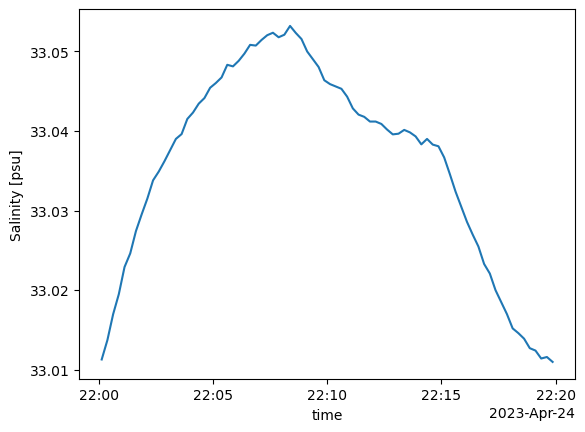

In [623]:
i=6
times_eddy = [
    ['2023-04-20T03:44:00', '2023-04-20T03:53:00'],
    ['2023-04-20T21:45:00', '2023-04-20T22:05:00'],
    ['2023-04-21T17:00:00', '2023-04-21T17:10:00'],
    ['2023-04-21T19:06:00', '2023-04-21T19:15:00'],
    ['2023-04-22T22:15:00', '2023-04-22T22:35:00'],
    ['2023-04-24T22:00:00', '2023-04-24T22:20:00'],
    ['2023-04-24T22:00:00', '2023-04-24T22:20:00']
]

uw_eddy = uw.sel(time=slice(times_eddy[i][0],times_eddy[i][1]))
uw_eddy.salt.plot()